# Scikit-learn

`sklearn` is one of the most popular Python libraries used for machine learning and data mining. It provides simple and efficient tools for data analysis and modeling, built on top of other libraries like NumPy, SciPy, and matplotlib.

**Rather than focusing on loading, manipulating and summarising data, Scikit-learn library
is focused on modeling the data**

**Supervised Learning algorithms:** Almost all the popular supervised learning
algorithms, like Linear Regression, Support Vector Machine (SVM), Decision Tree, KNN, Random Forest, Nive Bayes etc

**Unsupervised Learning algorithms:** Has all the popular
unsupervised learning algorithms from clustering, K-means clustering, mean shift, factor analysis, PCA (Principal
Component Analysis), tSNE, anomaly detection algorithms to unsupervised neural networks.

## Datasets in sklearn

Has several popular datasets that can be directly loaded for experimentation, learning, and testing machine learning algorithms

Covers different domains such as classification, regression, clustering, and even real-world problems

**Iris Dataset**:

    Type: Classification
    Description: It contains 150 samples of iris flowers, each with four features: sepal length, sepal width, petal length, and petal width. These flowers belong to three different species: setosa, versicolor, and virginica.
    Features: 4 features (sepal length, sepal width, petal length, petal width)
    Target: 3 classes (species of iris flowers)

from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data

y = iris.target


**Wine Dataset**:
    
    Type: Classification
    Description: The Wine dataset contains 178 samples of wine, each described by 13 features (chemical properties) such as alcohol content, malic acid, ash, alcalinity of ash, etc. The goal is to classify the wines into three classes (cultivars).
    Features: 13 features
    Target: 3 classes
    
from sklearn.datasets import load_wine

wine = load_wine()

X = wine.data

y = wine.target

**Breast Cancer Dataset**

**Diabetes Dataset**

**Digits Dataset**

**Boston Housing Dataset**

**California Housing Dataset**

**20 Newsgroups Dataset**


### Import

In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sklearn
from sklearn.datasets import load_iris

### Representation of Data in Scikit-learn

how data can be represented in order to be understood by the computer.

Most machine learning algorithms implemented in scikit-learn expect data to be stored in a two-dimensional array or matrix. The arrays can be either numpy arrays, or in some cases scipy.sparse matrices. The size of the array is expected to be [n_samples, n_features]

The number of features must be fixed in advance


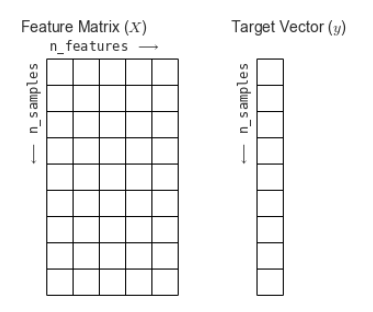

## Example: the Iris Dataset

In [2]:
from sklearn.datasets import load_iris
iris = load_iris()

In [2]:
n_samples, n_features = iris.data.shape
print((n_samples, n_features))
print(iris.data[0])
print(iris.target_names)

print(iris.filename)

(150, 4)
[5.1 3.5 1.4 0.2]
['setosa' 'versicolor' 'virginica']
iris.csv


In [3]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [4]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [3]:
import pandas as pd

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

In [6]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [7]:
# Save the DataFrame as a CSV file ??
df.to_csv("iris.csv")

In [3]:
X = iris.data

In [4]:
y = iris.target

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

**train_test_split**

- process of splitting data into different subsets (train set, test set, and validation set) is a fundamental practice in machine learning

- helps in assessing how well a model generalizes to unseen data, preventing overfitting, and ensuring that we build a robust mode

Why:
- When building machine learning models, we need to evaluate how well our model performs on new, unseen data
- If we train and test our model on the same data, the model could memorize the data (overfitting), leading to poor performance when applied to real-world data.

**Train set:** Used to train the model. The model learns patterns, relationships, and weights from this data.

**Test set:** Used to evaluate the model's performance on new data. This set is never seen during training, so it serves as a proxy for real-world data.


How Much:

**Training set:** 70-80% of the data.
**Test set:** 20-30% of the data.


### Train

In [6]:
from sklearn.neighbors import KNeighborsClassifier

classifier_knn = KNeighborsClassifier(n_neighbors=3)

classifier_knn.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [14]:
classifier_knn.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 3,
 'p': 2,
 'weights': 'uniform'}

### Inference

In [8]:
y_pred = classifier_knn.predict(X_test)

In [9]:
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0,
       0])

In [10]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [7]:
sample = [[4, 1, 2, 4]]
preds = classifier_knn.predict(sample)

preds

array([1])

In [8]:
from sklearn.datasets import load_iris
iris = load_iris()
pred = preds[0]
pred_species = iris.target_names[pred]
print("Predictions:", pred_species)

Predictions: versicolor


## Model Persistence

Once you train the model, it is desirable that the model should be persist for future use so that we do not need to retrain it again and again. It can be done with the help of dump and load features of **joblib** package.

or we can use **pickle**

In [9]:
import joblib

joblib.dump(classifier_knn, 'iris_classifier_knn_model.joblib')

['iris_classifier_knn_model.joblib']

In [1]:
import joblib

loaded_model = joblib.load('iris_classifier_knn_model.joblib')

In [2]:
sample = [[4, 1, 2, 4]]
preds = loaded_model.predict(sample)

preds

array([1])

In [ ]:
import pickle

with open('iris_classifier_knn_model.pkl', 'wb') as f:
    pickle.dump(classifier_knn, f)

In [ ]:
with open('iris_classifier_knn_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
    
y_pred = loaded_model.predict(X_test)


## Estimator API

Estimator API refers to the common interface used by all machine learning models and algorithms

Enabling different algorithms inference to be easily used, tuned, and validated, regardless of the specific model you're using

An Estimator is any object that can learn from data:

Classification (e.g., `KNeighborsClassifier`, `RandomForestClassifier`)

Regression (e.g., `LinearRegression`, `KNeighborsRegressor`)

Clustering (e.g., `KMeans`, `DBSCAN`)

Dimensionality Reduction (e.g., `PCA`, `TruncatedSVD`)

Transformers (e.g., `StandardScaler`, `OneHotEncoder`)






### Key Components of the Estimator API:

- `fit()` Method
- `predict()` Method
- `score()` Method: Used to evaluate the performance of a model
- `get_params()` and `set_params()` Methods: Allows us to inspect and modify the hyperparameters of a model

### Why Estimator concept?

1. Consistency: It provides a uniform interface across all scikit-learn models, making it easier to switch between different algorithms
2. Tuning: The get_params() and set_params() methods allow you to tune the hyperparameters of any estimator in a consistent way, which is important for hyperparameter optimization
3. Pipeline Integration: Scikit-learn's Pipelines make use of the Estimator API, allowing you to chain multiple preprocessing steps and models together into a single workflow

## Supervised Learning Example in `sklearn`

In [19]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np


Matplotlib is building the font cache; this may take a moment.


In [20]:
# Create random data for linear regression
rng = np.random.RandomState(35)
x = 10 * rng.rand(40)  # Generate 40 random x values scaled by 10

y = 2 * x - 1 + rng.randn(40)  # Create y with a linear relationship plus some noise


In [22]:
data = pd.DataFrame({'X': x, 'Y': y})
print(data.head())

          X          Y
0  4.580549   6.790195
1  3.083496   6.149635
2  2.314870   3.918440
3  2.774246   2.951180
4  8.172348  15.007651


In [23]:
X = x[:, np.newaxis]  # Reshape x into 2D array (scikit-learn expects the input features X to be a 2D array)


In [25]:
# Create the model
model = LinearRegression(fit_intercept=True)  # intercept True to make sure it doesnot pass through origin

In [26]:
model.fit(X, y)  # Train or fit

LinearRegression()

In [28]:
# Get model coefficients
print(model.coef_)  # Slope of the regression line
print(model.intercept_)  # Intercept of the regression line


[1.99839352]
-0.9895459457775146


In [29]:
# Generate values for the regression line
xfit = np.linspace(-1, 11)  # creates 100 evenly spaced numbers between -1 and 11
Xfit = xfit[:, np.newaxis]  # Reshape xfit into a 2D array


yfit = model.predict(Xfit)  # Predict the y values


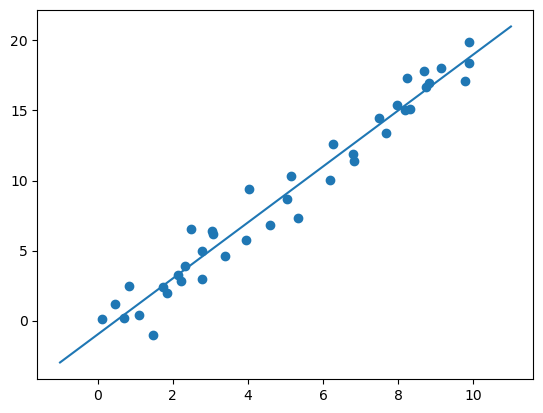

In [30]:
# Plot the data and regression line
plt.scatter(x, y)  # Scatter plot of the data
plt.plot(xfit, yfit)  # Plot the regression line
plt.show()

## Unsupervised Learning Example in `sklearn`

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

iris = sns.load_dataset('iris')

X_iris = iris.drop('species', axis = 1)
y_iris = iris['species']



In [32]:
from sklearn.decomposition import PCA

model = PCA(n_components=2)

model.fit(X_iris)

PCA(n_components=2)

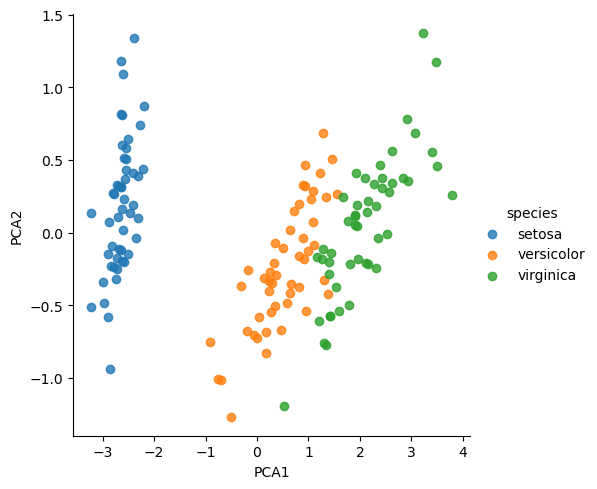

In [33]:
X_2D = model.transform(X_iris)

iris['PCA1'] = X_2D[:, 0]
iris['PCA2'] = X_2D[:, 1]

sns.lmplot(x="PCA1", y="PCA2", hue="species", data=iris, fit_reg=False)